In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import (
    basis, qeye, sigmax, sigmay, sigmaz, sigmap, sigmam,
    tensor, mesolve, expect
)


In [2]:
from dataclasses import dataclass, field, asdict
from typing import Optional
import numpy as np


@dataclass()
class QubitTLSParams:
    """
    Parameter container for a qubit coupled to a parasitic TLS.

    Hamiltonian:
        H = (ωq/2) σz ⊗ I
          + (ωtls/2) I ⊗ σz
          + g (σ+⊗σ- + σ-⊗σ+)

    All times are in the same simulation time-units.
    Frequencies are angular (rad/unit-time).
    """

    # -----------------------------------------------------------------
    # System frequencies
    # -----------------------------------------------------------------
    wq: float = 2 * np.pi * 5.0        # qubit frequency
    wtls: float = 2 * np.pi * 5.02     # TLS frequency
    g: float = 2 * np.pi * 0.02        # qubit–TLS coupling
    wd: float = 2 * np.pi * 5.0     # drive frequency (on qubit)
    Omega_d: float = 2 * np.pi * 0.1 # drive amplitude (on qubit)
    # -----------------------------------------------------------------
    # Qubit decoherence
    # -----------------------------------------------------------------
    T1_q: Optional[float] = None
    Tphi_q: Optional[float] = None

    # -----------------------------------------------------------------
    # TLS decoherence
    # -----------------------------------------------------------------
    T1_tls: Optional[float] = None
    Tphi_tls: Optional[float] = None

    # -----------------------------------------------------------------
    # Simulation control
    # -----------------------------------------------------------------
    tmax: float = 1000.0
    nt: int = 2001
    initial_state: str = "both_ground"

    # -----------------------------------------------------------------
    # Derived quantities (auto computed)
    # -----------------------------------------------------------------
    @property
    def detuning(self) -> float:
        return self.wq - self.wtls

    @property
    def Gamma1_q(self) -> float:
        return 0.0 if self.T1_q is None else 1.0 / self.T1_q

    @property
    def Gamma_phi_q(self) -> float:
        return 0.0 if self.Tphi_q is None else 1.0 / self.Tphi_q

    @property
    def Gamma1_tls(self) -> float:
        return 0.0 if self.T1_tls is None else 1.0 / self.T1_tls

    @property
    def Gamma_phi_tls(self) -> float:
        return 0.0 if self.Tphi_tls is None else 1.0 / self.Tphi_tls

    @property
    def T2_q(self) -> Optional[float]:
        if self.T1_q is None and self.Tphi_q is None:
            return None
        return 1.0 / (self.Gamma1_q/2 + self.Gamma_phi_q)

    @property
    def T2_tls(self) -> Optional[float]:
        if self.T1_tls is None and self.Tphi_tls is None:
            return None
        return 1.0 / (self.Gamma1_tls/2 + self.Gamma_phi_tls)

    def time_axis(self) -> np.ndarray:
        return np.linspace(0, self.tmax, self.nt)

    def to_dict(self):
        return asdict(self)

In [ ]:
from qutip import (
    basis, qeye, sigmaz, sigmap, sigmam,
    tensor
)
import numpy as np


def build_qubit_tls_model(params):

    I = qeye(2)

    # --- operators ---
    sz_q = tensor(sigmaz(), I)
    sp_q = tensor(sigmap(), I)
    sm_q = tensor(sigmam(), I)

    sz_tls = tensor(I, sigmaz())
    sp_tls = tensor(I, sigmap())
    sm_tls = tensor(I, sigmam())
    
    delta_q = params.wq - params.wd # drive detuning (on qubit)
    delta_tls = params.wtls - params.wd # drive detuning (on TLS)

    # --- Hamiltonian ---
    H0 = 0.5*delta_q*sz_q + 0.5*delta_tls*sz_tls
    Hint = params.g*(sp_q*sm_tls + sm_q*sp_tls)

    # --- Drive Hamiltonian ---
    sx_q = tensor(sigmap() + sigmam(), I)
    Hd = 0.5*params.Omega_d*sx_q # drive on qubit

    H = H0 + Hint+Hd

    # --- Collapse operators ---
    c_ops = []

    if params.T1_q:
        c_ops.append(np.sqrt(params.Gamma1_q) * sm_q)

    if params.Tphi_q:
        c_ops.append(np.sqrt(params.Gamma_phi_q/2) * sz_q)

    if params.T1_tls:
        c_ops.append(np.sqrt(params.Gamma1_tls) * sm_tls)

    if params.Tphi_tls:
        c_ops.append(np.sqrt(params.Gamma_phi_tls/2) * sz_tls)

    ops = {
        "n_q": sp_q * sm_q,
        "n_tls": sp_tls * sm_tls
    }

    return H, c_ops, ops

In [4]:
from qutip import mesolve, basis, tensor


def simulate_qubit_tls(params):

    H, c_ops, ops = build_qubit_tls_model(params)

    g = basis(2, 0)
    e = basis(2, 1)

    # --- Initial state from params ---
    if params.initial_state == "qubit_excited":
        psi0 = tensor(e, g)

    elif params.initial_state == "tls_excited":
        psi0 = tensor(g, e)

    elif params.initial_state == "both_ground":
        psi0 = tensor(e, e)

    else:
        raise ValueError("invalid initial_state")

    tlist = params.time_axis()

    result = mesolve(
        H,
        psi0,
        tlist,
        c_ops,
        [ops["n_q"], ops["n_tls"]]
    )

    return {
        "time": tlist,
        "Pq": result.expect[0],
        "Ptls": result.expect[1]
    }

In [20]:
params = QubitTLSParams(
    wq=2*np.pi*5.0,
    wd=2*np.pi*5.0,
    wtls=2*np.pi*4.5.0,
    g=2*np.pi*0.1,
    T1_q=800,
    Tphi_q=1200,
    T1_tls=400,
    Tphi_tls=700,
    tmax=1200,
    nt=3001
)
data = simulate_qubit_tls(params)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2592130815.py, line 4)

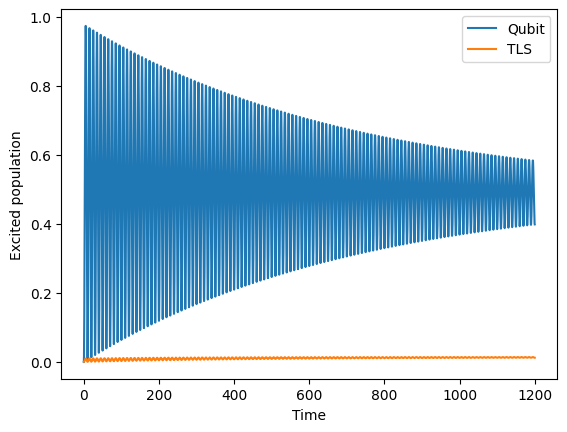

In [21]:
import matplotlib.pyplot as plt

plt.plot(data["time"], data["Pq"], label="Qubit")
plt.plot(data["time"], data["Ptls"], label="TLS")
plt.xlabel("Time")
plt.ylabel("Excited population")
plt.legend()
plt.show()

/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/.venv/lib/python3.12/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/.venv/lib/python3.12/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/.venv/lib/python3.12/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/.venv/lib/python3.12/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/.venv/lib/python3.12/site-packages/qutip/solver/solver_base.py

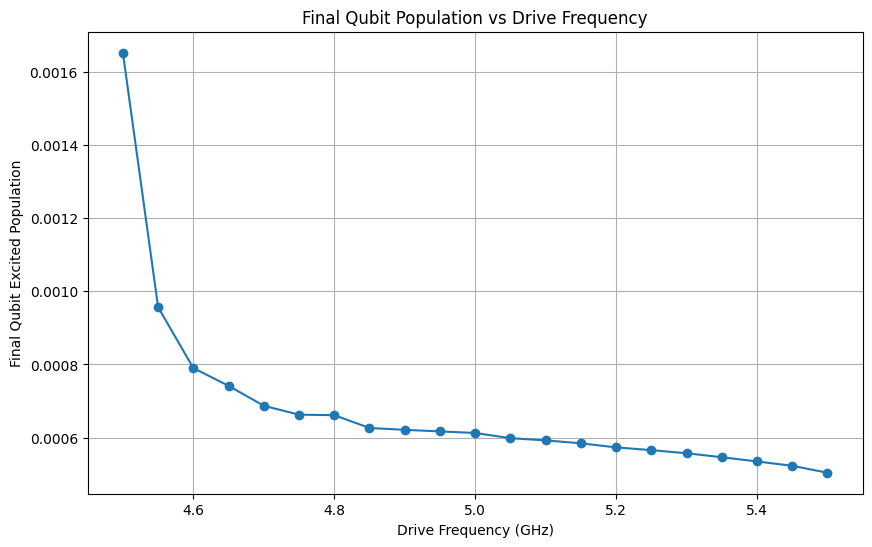

In [22]:
from qutip import parallel_map


def _spec(wd,params):
    params.wd = wd
    data = simulate_qubit_tls(params)
    pq_final = data["Pq"][-1]
    return pq_final



params.wq = 2*np.pi*2


wd_sweep = np.linspace(2*np.pi*4.5, 2*np.pi*5.5, 21)
    
    
def spec(wd_sweep, params):
    vec = parallel_map(
            _spec,
            wd_sweep,
            task_args=(params,),
        )
    
    return vec


vec = spec(wd_sweep, params)

    
    
plt.figure(figsize=(10, 6))
plt.plot(wd_sweep/(2*np.pi), vec, 'o-')
plt.xlabel("Drive Frequency (GHz)")
plt.ylabel("Final Qubit Excited Population")
plt.title("Final Qubit Population vs Drive Frequency")
plt.grid(True)
plt.show()





/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/.venv/lib/python3.12/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/.venv/lib/python3.12/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/.venv/lib/python3.12/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/.venv/lib/python3.12/site-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
/Users/asafsolonnikov/Developer/amplitude-robust-spectroscopy/.venv/lib/python3.12/site-packages/qutip/solver/solver_base.py

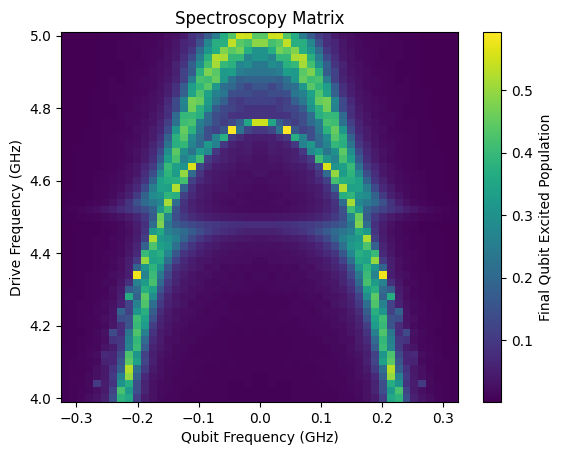

In [32]:
wd_sweep = np.linspace(2*np.pi*4, 2*np.pi*5, 51)
wq0 = 5*2*np.pi

flux_sweep = np.linspace(-2, 2, 50)


def flux_to_wq(flux):
    wq = 5*2*np.pi
    wq += -flux**2*0.1*wq
    return wq

wq_sweep = flux_to_wq(flux_sweep)

# plt.plot(flux_sweep, flux_to_wq(flux_sweep)/(2*np.pi), 'o-')


spec_matrix = []
for flux in flux_sweep:

    wq = flux_to_wq(flux)

    params = QubitTLSParams(
        wq=wq,
        wd=2*np.pi*5.0,
        wtls=2*np.pi*4.5,
        g=2*np.pi*0.1,
        T1_q=800,
        Tphi_q=1200,
        T1_tls=400,
        Tphi_tls=700,
        tmax=1200,
        nt=3001
    )

    spec_matrix.append(spec(wd_sweep, params))

spec_matrix = np.array(spec_matrix)




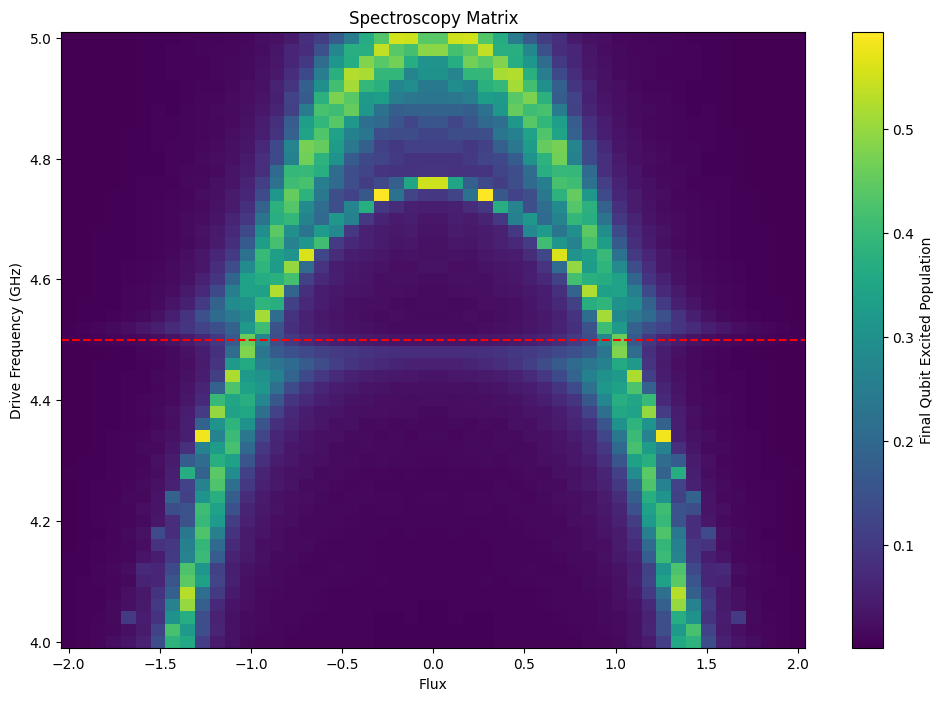

In [37]:
spec_matrix = np.array(spec_matrix)


plt.figure(figsize=(12, 8))
plt.pcolormesh(flux_sweep, wd_sweep/(2*np.pi), np.array(spec_matrix).T, shading='auto')
plt.xlabel("Flux")
plt.axhline(y=4.5, color='r', linestyle='--', label="Qubit Frequency")
plt.ylabel("Drive Frequency (GHz)")
plt.title("Spectroscopy Matrix")
plt.colorbar(label="Final Qubit Excited Population")
plt.show()